# Trực quan hóa kết quả mô hình

Notebook này cung cấp các ô để:

- Nạp checkpoint đã huấn luyện và đánh giá trên tập test.
- Vẽ ma trận nhầm lẫn (confusion matrix) và báo cáo phân loại (classification report).
- Nếu có lịch sử huấn luyện (log), vẽ đường loss/accuracy theo epoch.

Chạy từng ô theo thứ tự; cập nhật đường dẫn `ckpt_path` tới checkpoint bạn đã lưu.

## 4.3. Kết quả huấn luyện (So sánh Baseline vs Pre-Norm)

### 4.3.1. Đường cong huấn luyện (Training Curves)

Biểu đồ loss và accuracy cho thấy Pre-Norm Transformer hội tụ nhanh hơn và ổn định hơn so với Standard Transformer (Post-Norm). Ngay từ những epoch đầu, Pre-Norm đã có train loss thấp hơn và validation accuracy cao hơn. Đường train loss của Pre-Norm giảm đều từ khoảng 0.467 xuống 0.132, trong khi validation accuracy dao động rất hẹp quanh mức 0.89–0.90 và đạt đỉnh 0.9009.

Ngược lại, Post-Norm giảm chậm hơn và dao động mạnh hơn trong giai đoạn đầu, đặc biệt validation accuracy có lúc giảm xuống dưới 0.78 trước khi phục hồi. Điều này cho thấy quá trình tối ưu của Pre-Norm mượt hơn, ít biến động hơn và đạt trạng thái hội tụ tốt hơn trên bộ dữ liệu AG News.

### 4.3.2. Đánh giá trên tập kiểm thử (Test Set)

| Mô hình | Accuracy | F1-Macro | F1-Micro |
| --- | ---: | ---: | ---: |
| Pre-Norm Transformer | 0.9009 | 0.9006 | 0.9009 |
| Standard Transformer (Post-Norm) | 0.8714 | 0.8706 | 0.8714 |

Pre-Norm Transformer vượt Post-Norm khoảng 2.95 điểm phần trăm về Accuracy và khoảng 2.99 điểm phần trăm về F1-Macro. Với bài toán phân loại đa lớp một nhãn, F1-Micro trùng với Accuracy, nên bảng trên phản ánh trực tiếp chất lượng dự đoán tổng thể của hai mô hình.

Phân tích confusion matrix của Pre-Norm cho thấy cặp lớp dễ bị nhầm lẫn nhất là **Business** và **Sci/Tech**. Cụ thể, mẫu thuộc Business bị dự đoán thành Sci/Tech 177 lần, còn Sci/Tech bị dự đoán thành Business 119 lần. Đây là hai chủ đề có nhiều từ vựng giao thoa liên quan đến công ty, sản phẩm, thị trường và công nghệ, nên mô hình khó tách bạch hoàn toàn.

Ngược lại, các lớp **Sports** và **World** có độ phân biệt tốt hơn, số lượng nhầm lẫn thấp hơn đáng kể. Điều này cho thấy Pre-Norm nhìn chung học được biên quyết định tốt, nhưng vẫn còn hạn chế khi hai chủ đề có ngữ cảnh gần nhau về mặt từ vựng và chủ đề.


Bảng so sánh kết quả cuối cùng:


,model,checkpoint,test_accuracy,test_f1_macro
0,prenorm,checkpoints\prenorm_1779095612.pt,0.900921,0.900558
1,postnorm,checkpoints\postnorm_1779096147.pt,0.871447,0.870641


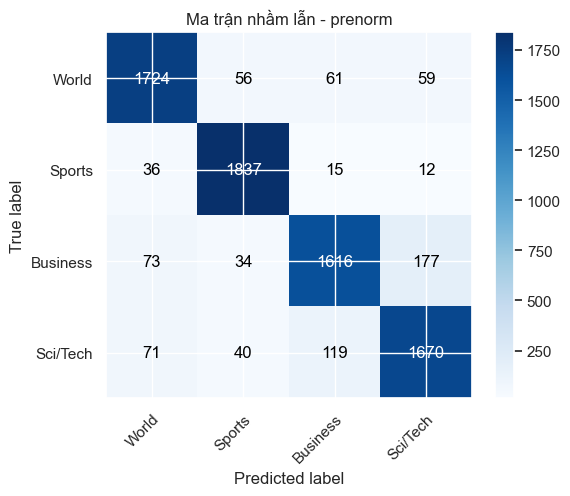

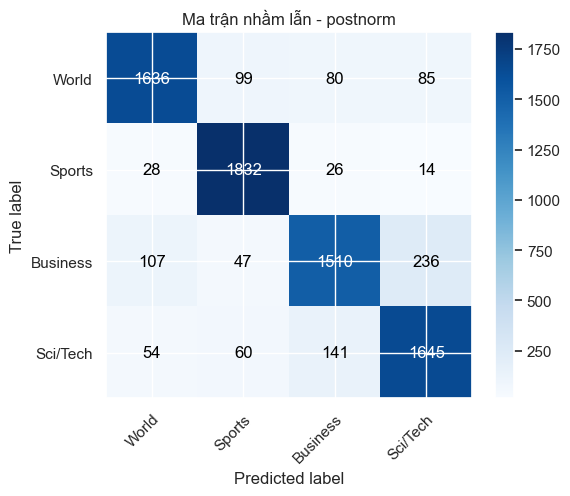

Đang vẽ history từ: d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\notebooks\logs\history_postnorm_1779096147.csv


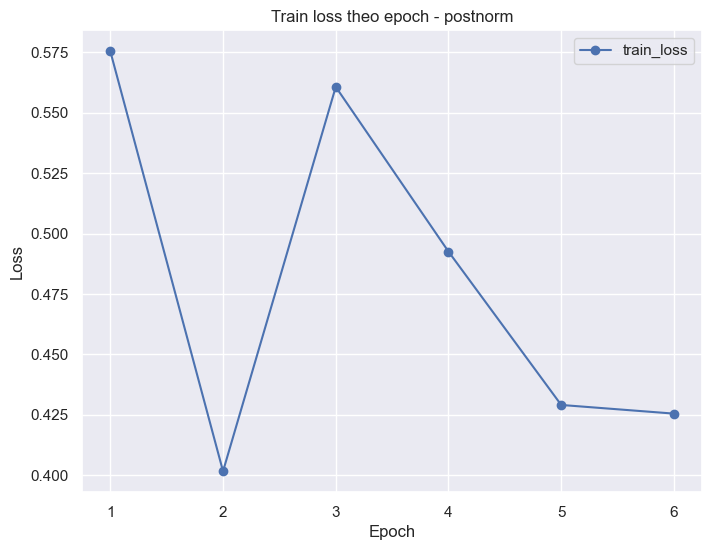

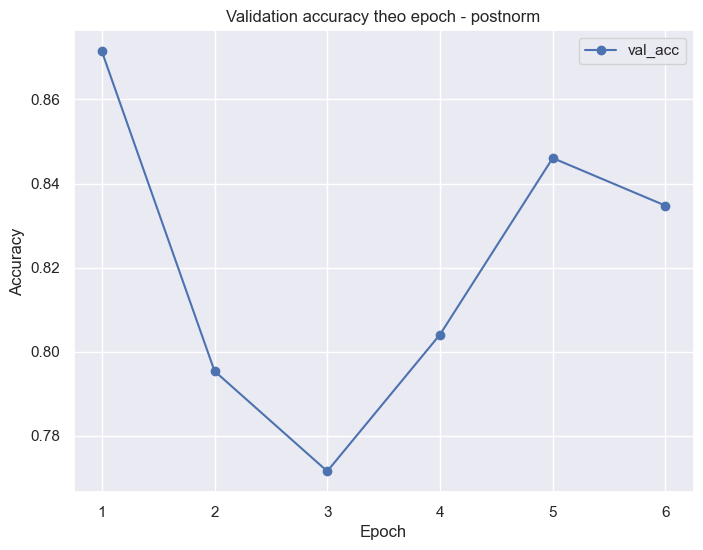

Đang vẽ history từ: d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\notebooks\logs\history_prenorm_1779095612.csv


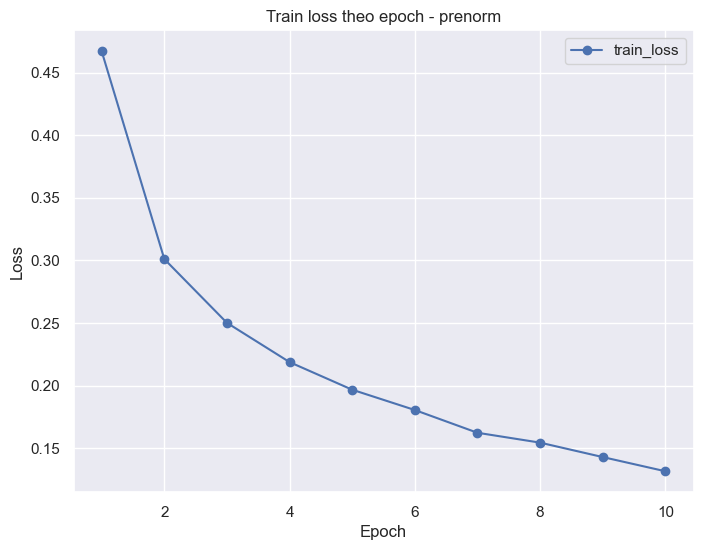

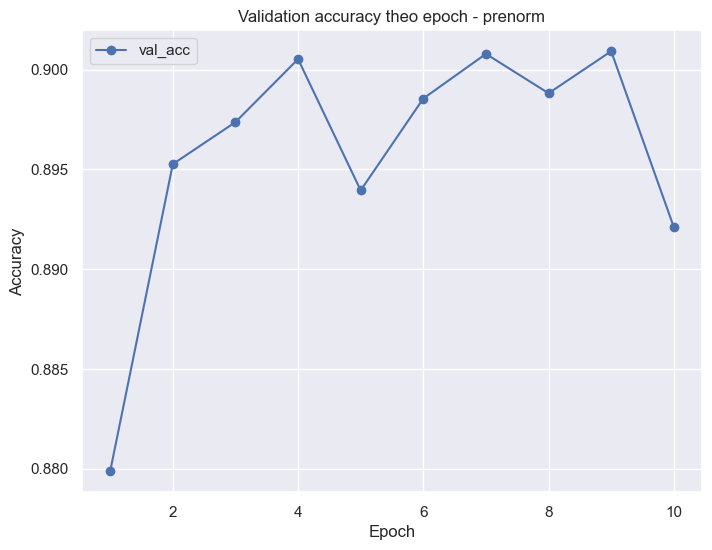

Bảng so sánh mở rộng (micro F1 trùng với accuracy trong bài toán đa lớp một nhãn):


,Model,Accuracy,F1-Macro,F1-Micro
0,Pre-Norm Transformer,0.900921,0.900558,0.900921
1,Standard Transformer (Post-Norm),0.871447,0.870641,0.871447


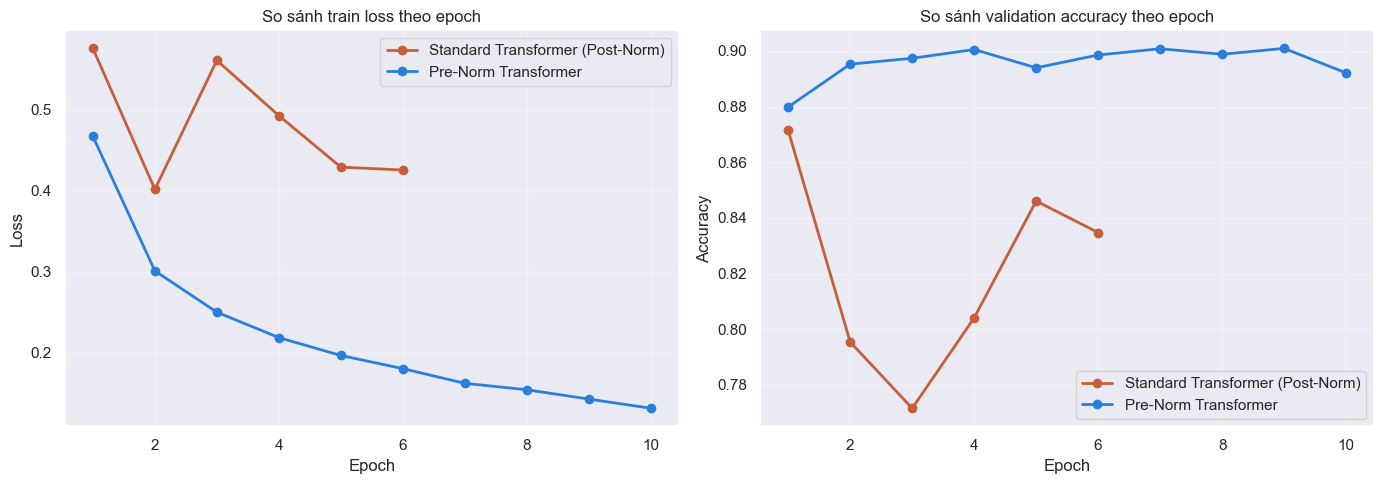

Pre-Norm đạt val_acc cao nhất = 0.9009 và train_loss cuối = 0.1317.
Post-Norm đạt val_acc cao nhất = 0.8714 và train_loss cuối = 0.4255.
Các cặp nhầm lẫn lớn nhất của Pre-Norm:
- Business -> Sci/Tech: 177
- Sci/Tech -> Business: 119
- Business -> World: 73


In [1]:
# Imports và trực quan từ kết quả đã lưu trong results/
import os
import sys
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set()
plt.rcParams['figure.figsize'] = (8, 6)

project_root = os.getcwd()
if not os.path.exists(os.path.join(project_root, 'train.py')):
    parent_root = os.path.abspath(os.path.join(project_root, '..'))
    if os.path.exists(os.path.join(parent_root, 'train.py')):
        project_root = parent_root
    else:
        repo_root = os.path.join(project_root, '-DL-Prenorm-Transformer-AGnews')
        if os.path.exists(os.path.join(repo_root, 'train.py')):
            project_root = repo_root
results_dir = os.path.join(project_root, 'results')
log_dirs = [
    os.path.join(project_root, 'logs'),
    os.path.join(project_root, 'notebooks', 'logs'),
    os.path.join(os.getcwd(), 'logs'),
]

# 1) Hiển thị bảng so sánh cuối cùng
comparison_path = os.path.join(results_dir, 'comparison_results.csv')
if os.path.exists(comparison_path):
    df = pd.read_csv(comparison_path)
    print('Bảng so sánh kết quả cuối cùng:')
    display(df)
else:
    print('Chưa có file comparison_results.csv. Hãy chạy notebook 03 trước.')

# 2) Vẽ confusion matrix của 2 mô hình
cm_path = os.path.join(results_dir, 'confusion_matrices.json')
labels = ['World', 'Sports', 'Business', 'Sci/Tech']

if os.path.exists(cm_path):
    with open(cm_path, 'r', encoding='utf-8') as f:
        cms = json.load(f)

    for model_name in ['prenorm', 'postnorm']:
        if model_name not in cms:
            continue
        cm = np.array(cms[model_name])
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        ax.set(
            xticks=np.arange(len(labels)),
            yticks=np.arange(len(labels)),
            xticklabels=labels,
            yticklabels=labels,
            ylabel='True label',
            xlabel='Predicted label',
            title=f'Ma trận nhầm lẫn - {model_name}'
        )
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        thresh = cm.max() / 2.0 if cm.size > 0 else 0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > thresh else 'black')

        plt.tight_layout()
        plt.show()
else:
    print('Chưa có file confusion_matrices.json. Hãy chạy notebook 03 trước.')

# 3) Vẽ đường train_loss và val_acc từ log history_*.csv
history_files = []
for log_dir in log_dirs:
    history_files.extend(sorted(glob.glob(os.path.join(log_dir, 'history_*.csv'))))
history_files = sorted(set(history_files))
if history_files:
    for hp in history_files:
        hdf = pd.read_csv(hp)
        model_name = os.path.basename(hp).replace('history_', '').split('_')[0]
        print('Đang vẽ history từ:', hp)

        plt.figure()
        plt.plot(hdf['epoch'], hdf['train_loss'], marker='o', label='train_loss')
        plt.title(f'Train loss theo epoch - {model_name}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        if 'val_acc' in hdf.columns:
            plt.figure()
            plt.plot(hdf['epoch'], hdf['val_acc'], marker='o', label='val_acc')
            plt.title(f'Validation accuracy theo epoch - {model_name}')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.show()
else:
    print('Không tìm thấy history_*.csv trong bất kỳ thư mục logs nào.')

# 4.3.1 Biểu đồ so sánh trực tiếp giữa hai mô hình
if os.path.exists(comparison_path):
    comparison_df = pd.read_csv(comparison_path).copy()
    comparison_df['test_f1_micro'] = comparison_df['test_accuracy']
    comparison_df['model'] = comparison_df['model'].replace({
        'postnorm': 'Standard Transformer (Post-Norm)',
        'prenorm': 'Pre-Norm Transformer',
    })
    print('Bảng so sánh mở rộng (micro F1 trùng với accuracy trong bài toán đa lớp một nhãn):')
    display(
        comparison_df[['model', 'test_accuracy', 'test_f1_macro', 'test_f1_micro']]
        .rename(columns={
            'model': 'Model',
            'test_accuracy': 'Accuracy',
            'test_f1_macro': 'F1-Macro',
            'test_f1_micro': 'F1-Micro',
        })
    )
else:
    print('Chưa tìm thấy comparison_results.csv để lập bảng so sánh.')

history_map = {}
for hp in history_files:
    hdf = pd.read_csv(hp).sort_values('epoch')
    model_key = os.path.basename(hp).replace('history_', '').split('_')[0]
    history_map[model_key] = hdf

if 'prenorm' in history_map and 'postnorm' in history_map:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    styles = {
        'postnorm': {'label': 'Standard Transformer (Post-Norm)', 'color': '#C65D3B'},
        'prenorm': {'label': 'Pre-Norm Transformer', 'color': '#2A7FDB'},
    }

    for model_key in ['postnorm', 'prenorm']:
        hdf = history_map[model_key]
        axes[0].plot(
            hdf['epoch'],
            hdf['train_loss'],
            marker='o',
            linewidth=2,
            label=styles[model_key]['label'],
            color=styles[model_key]['color']
        )
        axes[1].plot(
            hdf['epoch'],
            hdf['val_acc'],
            marker='o',
            linewidth=2,
            label=styles[model_key]['label'],
            color=styles[model_key]['color']
        )

    axes[0].set_title('So sánh train loss theo epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title('So sánh validation accuracy theo epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    prenorm_curve = history_map['prenorm']
    postnorm_curve = history_map['postnorm']
    print(
        f"Pre-Norm đạt val_acc cao nhất = {prenorm_curve['val_acc'].max():.4f} "
        f"và train_loss cuối = {prenorm_curve['train_loss'].iloc[-1]:.4f}."
    )
    print(
        f"Post-Norm đạt val_acc cao nhất = {postnorm_curve['val_acc'].max():.4f} "
        f"và train_loss cuối = {postnorm_curve['train_loss'].iloc[-1]:.4f}."
    )
else:
    print('Không đủ history_*.csv cho cả hai mô hình để vẽ biểu đồ so sánh trực tiếp.')

# Phân tích cặp nhầm lẫn lớn nhất của Pre-Norm Transformer
if os.path.exists(cm_path):
    with open(cm_path, 'r', encoding='utf-8') as f:
        cms = json.load(f)

    if 'prenorm' in cms:
        prenorm_cm = np.array(cms['prenorm'])
        off_diag = prenorm_cm.copy()
        np.fill_diagonal(off_diag, 0)
        flat_indices = np.argsort(off_diag, axis=None)[::-1]
        print('Các cặp nhầm lẫn lớn nhất của Pre-Norm:')
        printed = 0
        for flat_index in flat_indices:
            count = int(off_diag.flat[flat_index])
            if count == 0:
                break
            true_idx, pred_idx = np.unravel_index(flat_index, off_diag.shape)
            print(f'- {labels[true_idx]} -> {labels[pred_idx]}: {count}')
            printed += 1
            if printed == 3:
                break
    else:
        print('Không tìm thấy ma trận nhầm lẫn của prenorm trong confusion_matrices.json.')
else:
    print('Chưa có file confusion_matrices.json. Hãy chạy notebook 03 trước.')